In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

In [3]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

In [4]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [5]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


In [6]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


In [7]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


In [8]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [9]:
df_filled = df_drop.copy()
df_filled['Age' ] = df['Age' ].fillna(df['Age' ].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [10]:
df_filled['Shoe Chart' ] = df['Shoe Chart' ]. fillna(df['Shoe Chart' ].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Fav Fruit' ] = df['Fav Fruit' ].fillna(df['Fav Fruit' ].mode() .iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


In [12]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [13]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


In [14]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [16]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


<Axes: ylabel='Height'>

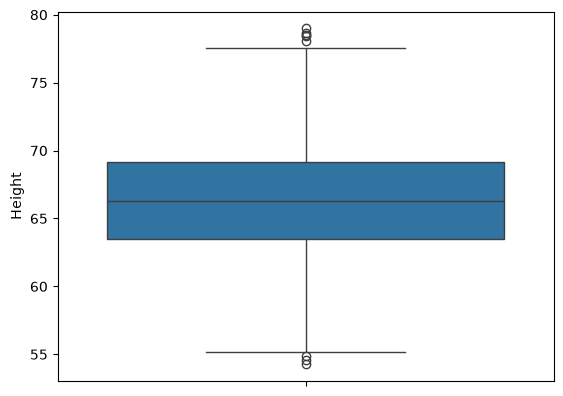

In [17]:
import seaborn as sns

sns.boxplot(df2['Height'])

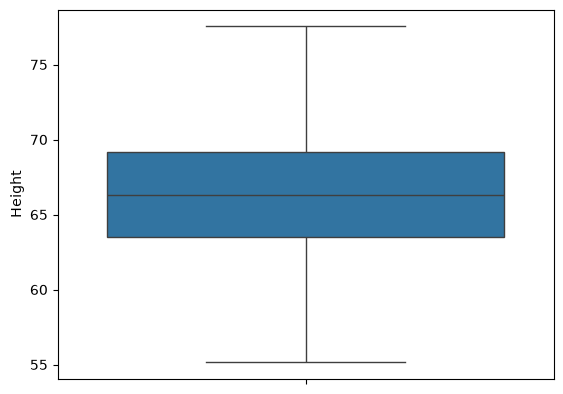

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Identifikasi Q1 dan Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])

# Hitung IQR
iqr = q3 - q1

# Cari batas bawah dan batas atas
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Hapus outlier
clean_data = df2[(df2['Height'] >= lower_bound) &
(df2['Height'] <= upper_bound)]

# Tampilkan boxplot
sns.boxplot(y=clean_data[ 'Height'])

plt.ylabel('Height')
plt.show()

<Axes: ylabel='Weight'>

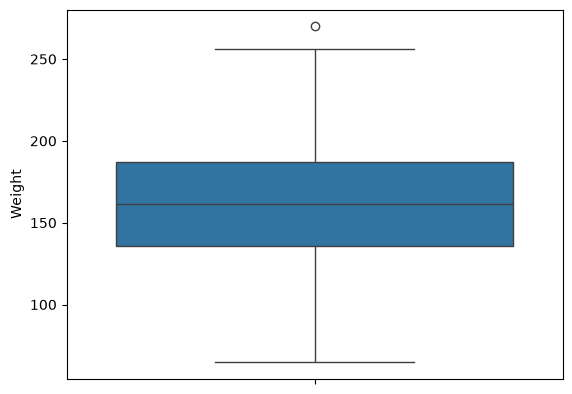

In [23]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

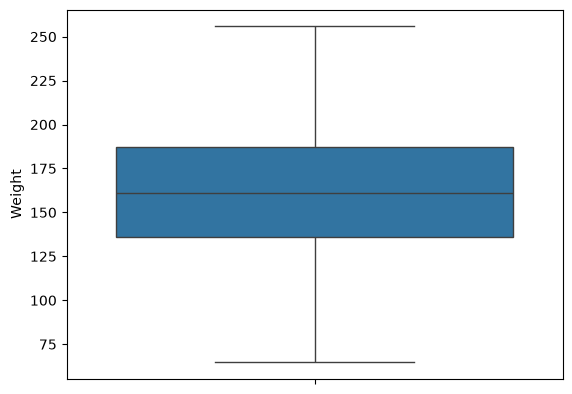

In [25]:
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])
# Hitung IQR
iqr = q3 - q1

# Cari Lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Weight'] >= lower_bound)
& (df2['Weight'] <= upper_bound)]

sns.boxplot(clean_data['Weight'])

C:\Users\sthab\AppData\Local\Temp\ipykernel_10652\1643810257.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


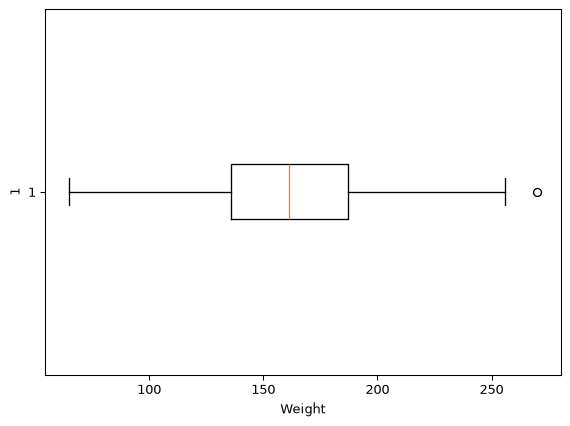

In [32]:
import matplotlib.pyplot as plt

columns_to_plot = ['Weight']

fig, ax = plt.subplots(
1,

1,
dpi=95,
figsize=(7, 5)

)

ax.boxplot(
df2['Weight'].dropna(),
vert=False

)

ax.set_xlabel('Weight')
ax.set_ylabel('1')

plt.show()

C:\Users\sthab\AppData\Local\Temp\ipykernel_10652\1788482160.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\sthab\AppData\Local\Temp\ipykernel_10652\1788482160.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


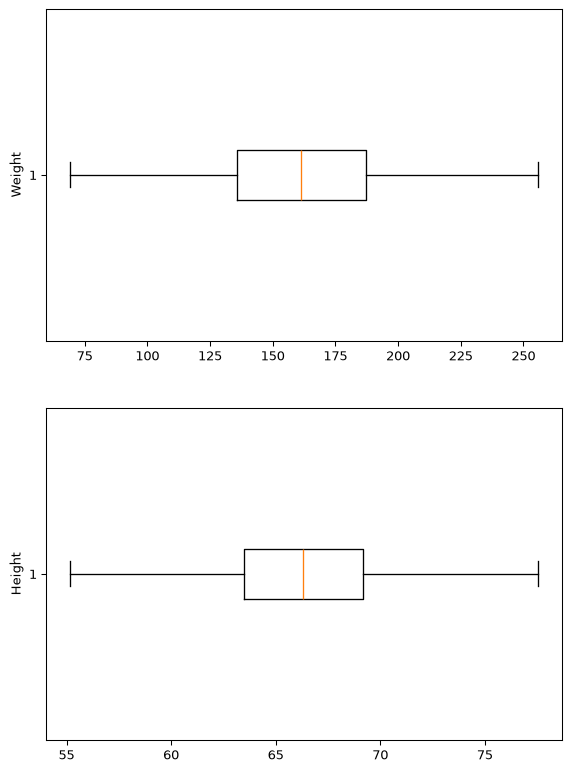

In [44]:
import numpy as np
import matplotlib.pyplot as plt
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) &
            (df_cleaned[col] <= upper_bound)
        ]
    return df_cleaned
# Terapkan fungsi untuk menghapus outliers dari
"Height","Weight"
clean_data = remove_outliers_sequentially(
    df2,
    ['Height', 'Weight']
)
# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(
len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7,5* len(columns_to_plot))
)
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

In [46]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 865.6 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/8.4 MB 865.6 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/8.4 MB 865.6 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.4 MB 568.2 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.4 MB 568.2 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.4 MB 568.2 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.4 MB 568.2 kB/s eta 0:00:14
   --- ---------------------------------

In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(include=[np.number ]) .columns # Ambil kolom
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number ]).columns # Ambil k

rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[ :]

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [50]:
# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data)

# Gabungkan kembali dengan kolom non-numerik tanpa mengubah jumlah baris
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)

final_df

,Gender,Height,Weight
0,Male,NaN,NaN
1,Male,NaN,NaN
2,Male,NaN,NaN
3,Male,NaN,NaN
4,Male,NaN,NaN
...,...,...,...
"(Female, 66.1726521477708, 136.777454183235)",NaN,0.492177,0.362771
"(Female, 67.067154649054, 170.867905890713)",NaN,0.532113,0.545189
"(Female, 63.8679922137577, 128.475318784122)",NaN,0.389284,0.318346
"(Female, 69.0342431307346, 163.852461346571)",NaN,0.619935,0.507649


In [1]:
#Tugas 2
import pandas as pd

# Membaca dataset Titanic

df = pd.read_csv('Titanic-Dataset.csv')

# Melihat missing value sebelum ditangani
print("Missing value sebelum ditangani:")
print(df.isnull().sum())

# Mengatasi missing value pada Age dengan median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Mengatasi missing value pada Cabin dengan Unknown
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Mengatasi missing value pada Embarked dengan modus
df['Embarked'] = df['Embarked'].fillna(df['Embarked' ].mode()[0])

# Menampilkan missing value setelah ditangani
print("\nMissing value setelah ditangani:")
print(df.isnull().sum())

Missing value sebelum ditangani:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing value setelah ditangani:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [2]:
#Tugas 3 Handling Outliers Dataset "Diabetes"

#3 kolom numerik yang cocok yaitu Glucose, BLoodPressure, BMI

#Baca dataset
import pandas as pd
import matplotlib.pyplot as plt

# Membaca dataset diabetes
diabetes = pd.read_csv('diabetes.csv')

# Melihat 5 data pertama
diabetes .head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


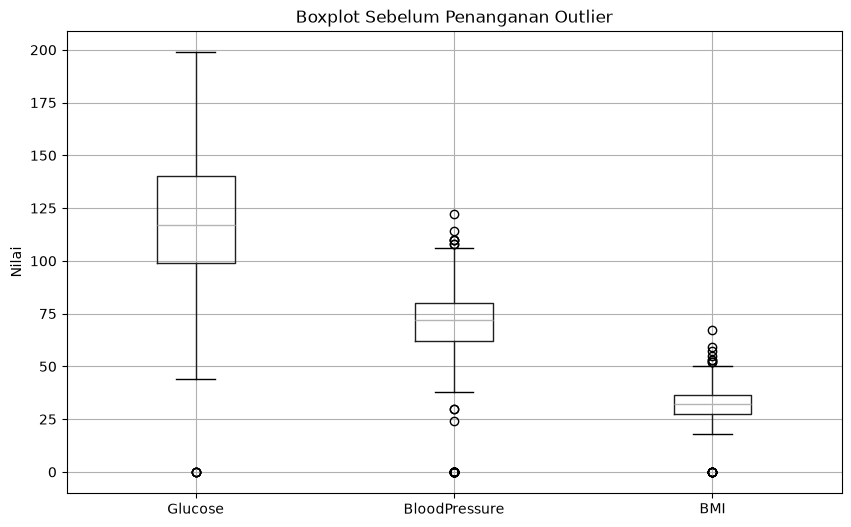

In [3]:
# Kolom yang dipilih
columns = ['Glucose', 'BloodPressure', 'BMI']

# Membuat boxplot
plt.figure(figsize=(10, 6))

diabetes[columns ] .boxplot()

plt.title('Boxplot Sebelum Penanganan Outlier')
plt.ylabel('Nilai')
plt.show()

In [ ]:
#Menghitung jumlah outlier
for col in columns:
    Q1 = diabetes[col].quantile(0.25)
    Q3 = diabetes[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = diabetes[
    (diabetes[col] < lower_bound) |
    (diabetes[col] > upper_bound)
    ]
    
    print("Kolom:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Batas bawah:", lower_bound)
    print("Batas atas:", upper_bound)
    print("Jumlah outlier:", len(outliers))
    print("--------------------------------")

Kolom: Glucose
Q1: 99.0
Q3: 140.25
IQR: 41.25
Batas bawah: 37.125
Batas atas: 202.125
Jumlah outlier: 5
--------------------------------
Kolom: BloodPressure
Q1: 62.0
Q3: 80.0
IQR: 18.0
Batas bawah: 35.0
Batas atas: 107.0
Jumlah outlier: 45
--------------------------------
Kolom: BMI
Q1: 27.3
Q3: 36.6
IQR: 9.3
Batas bawah: 13.35
Batas atas: 50.550000000000004
Jumlah outlier: 19
--------------------------------
